# t-SNE — an interactive, visual notebook

This notebook is a *hands-on companion* to the lecture slides **“t-distributed Stochastic Neighborhood Embedding (t‑SNE)”**.

It’s designed to help you **see** each concept (probabilities, perplexity, crowding problem, KL divergence, gradients, optimization tricks, and pitfalls) with interactive visuals.

---

## What you’ll need

- Python ≥ 3.9  
- `numpy`, `scipy`, `scikit-learn`, `matplotlib`, `plotly`

Optional but recommended for richer interactivity:
- `ipywidgets`

If widgets are not available, the notebook will still run — you’ll just rerun cells to change parameters.


In [1]:
# Core scientific stack
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_digits, make_swiss_roll, make_s_curve
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, trustworthiness
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from sklearn.neighbors import NearestNeighbors

import plotly.express as px
import plotly.graph_objects as go

from time import perf_counter

np.random.seed(0)

# Optional widgets
try:
    import ipywidgets as widgets
    from IPython.display import display
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False

print("Widgets available:", HAS_WIDGETS)


Widgets available: True


---

# 1) Motivation and where t-SNE fits

t-SNE is mainly used for **exploration and visualization**. It tries to keep **nearby points nearby** when moving from high‑D to 2‑D/3‑D.

A good mental model:

- **PCA**: best *linear* projection; preserves global variance directions.
- **t‑SNE**: best *nonlinear* “neighborhood map”; preserves local neighborhoods.
- **Do not** interpret t‑SNE as a faithful map of global distances, densities, or axes.

We’ll use the **digits** dataset (1797 handwritten digits, 64 features) for most demos.


X: (1797, 64) y: (1797,) classes: [0 1 2 3 4 5 6 7 8 9]


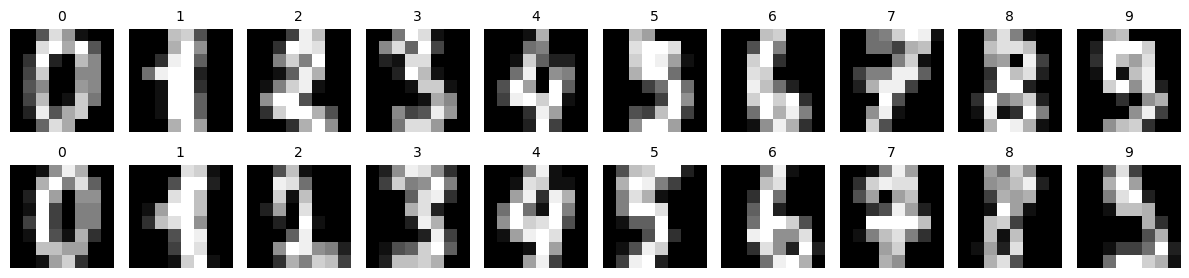

In [2]:
digits = load_digits()
X = digits.data.astype(np.float64)
y = digits.target.astype(int)

print("X:", X.shape, "y:", y.shape, "classes:", np.unique(y))

# A quick peek at a few images
fig, axes = plt.subplots(2, 10, figsize=(12, 3))
for ax, idx in zip(axes.ravel(), range(20)):
    ax.imshow(digits.images[idx], cmap="gray")
    ax.set_title(str(y[idx]), fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()


### PCA vs t‑SNE: first intuition

Below we compare:

- PCA (2D)
- t‑SNE (2D)

The plotly scatter is interactive (zoom + hover).


In [3]:
# Preprocess the data (recommended in the lecture): scale, then optionally PCA
X_scaled = StandardScaler().fit_transform(X)

pca2 = PCA(n_components=2, random_state=0)
X_pca2 = pca2.fit_transform(X_scaled)

# Keep t-SNE small-ish for responsiveness
idx = np.random.RandomState(0).choice(len(X_scaled), size=1200, replace=False)
X_small = X_scaled[idx]
y_small = y[idx]
X_pca2_small = X_pca2[idx]

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    max_iter=800,
    random_state=0,
)
X_tsne2 = tsne.fit_transform(X_small)

fig1 = px.scatter(x=X_pca2_small[:,0], y=X_pca2_small[:,1], color=y_small.astype(str),
                  title="PCA (2D) on digits (interactive)", opacity=0.7)
fig1.show()

fig2 = px.scatter(x=X_tsne2[:,0], y=X_tsne2[:,1], color=y_small.astype(str),
                  title="t-SNE (2D) on digits (interactive)", opacity=0.7)
fig2.show()


---

# 2) Why raw distances get tricky in high dimensions

A key motivation in the slides: **distances “concentrate”** in high dimensions.

For random points in a hypercube, the closest and farthest distances become *similar* as dimension grows.
That makes “neighborhood” definitions based on raw distance less intuitive.

We’ll visualize this with a slider-like plotly control.


In [4]:
def distance_concentration_demo(n=800, dims=(2, 5, 10, 20, 50, 100), seed=0):
    rng = np.random.RandomState(seed)
    frames = []
    base = None

    for d in dims:
        Xd = rng.rand(n, d)
        # Sample pairwise distances without forming the full matrix (cheap approximation)
        a = rng.randint(0, n, size=6000)
        b = rng.randint(0, n, size=6000)
        dist = np.linalg.norm(Xd[a] - Xd[b], axis=1)
        hist, edges = np.histogram(dist, bins=50, density=True)
        x = 0.5*(edges[:-1] + edges[1:])
        frames.append(go.Frame(data=[go.Scatter(x=x, y=hist, mode="lines")], name=str(d)))
        if base is None:
            base = (x, hist)

    fig = go.Figure(
        data=[go.Scatter(x=base[0], y=base[1], mode="lines")],
        layout=go.Layout(
            title="Distance concentration as dimension increases (random points in [0,1]^d)",
            xaxis_title="Euclidean distance",
            yaxis_title="Density",
            updatemenus=[{
                "type": "buttons",
                "showactive": True,
                "buttons": [
                    {"label": "Play", "method": "animate", "args": [None, {"frame": {"duration": 800, "redraw": True}}]},
                    {"label": "Pause", "method": "animate", "args": [[None], {"frame": {"duration": 0, "redraw": False}}]},
                ],
            }],
            sliders=[{
                "steps": [{"method": "animate",
                           "args": [[str(d)], {"mode": "immediate", "frame": {"duration": 0, "redraw": True}}],
                           "label": str(d)} for d in dims],
                "currentvalue": {"prefix": "dimension = "}
            }],
        ),
        frames=frames
    )
    return fig

distance_concentration_demo().show()


---

# 3) Core pipeline of t‑SNE (big picture)

t‑SNE builds two probability distributions:

1. **High‑D similarities** \(P\): “who is a neighbor of whom” in the original space  
2. **Low‑D similarities** \(Q\): “who is a neighbor of whom” in the embedding

Then it finds embedding points \(\{y_i\}\) that make \(Q\) match \(P\) by minimizing **KL divergence**:

\[
\mathcal{L} = KL(P \,\|\, Q) = \sum_{i \neq j} p_{ij}\log\frac{p_{ij}}{q_{ij}}
\]

We'll now build each piece from scratch on small subsets to keep things visual and fast.


---

# 4) Step 1 — Conditional neighborhood probabilities \(p_{j|i}\)

For each point \(x_i\), t‑SNE defines a conditional distribution over all other points:

\[
p_{j|i} = \frac{\exp\left(-\|x_i-x_j\|^2 \,/\, 2\sigma_i^2\right)}
{\sum_{k\neq i}\exp\left(-\|x_i-x_k\|^2 \,/\, 2\sigma_i^2\right)},\quad p_{i|i}=0
\]

- It is a **Gaussian kernel** centered at \(x_i\).
- **Local bandwidth** \(\sigma_i\) adapts to local density (dense regions → smaller \(\sigma_i\)).

We’ll compute \(p_{j|i}\) for one point and visualize the probability mass over its nearest neighbors.


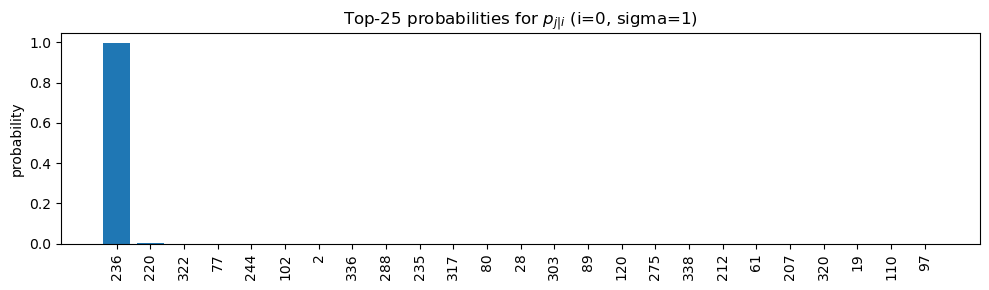

In [5]:
def p_conditional_for_point(X, i, sigma):
    # Return p_{j|i} over all j for a fixed i (with p_{i|i}=0).
    d2 = np.sum((X - X[i])**2, axis=1)
    d2[i] = np.inf
    w = np.exp(-d2 / (2.0 * sigma**2))
    w[i] = 0.0
    s = w.sum()
    if s == 0:
        return w
    return w / s

def show_p_neighbors(X, i=0, sigma=1.0, topk=20):
    p = p_conditional_for_point(X, i, sigma)
    nn = np.argsort(-p)[:topk]
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.bar(range(topk), p[nn])
    ax.set_xticks(range(topk))
    ax.set_xticklabels(nn, rotation=90)
    ax.set_title(rf"Top-{topk} probabilities for $p_{{j|i}}$ (i={i}, sigma={sigma:.3g})")
    ax.set_ylabel("probability")
    plt.tight_layout()
    plt.show()

# Use a small, scaled subset for clarity
rng = np.random.RandomState(0)
idx_demo = rng.choice(len(X_scaled), size=350, replace=False)
X_demo = X_scaled[idx_demo]
y_demo = y[idx_demo]

show_p_neighbors(X_demo, i=0, sigma=1.0, topk=25)


### Interactive view (optional widgets)

Pick a point index and a bandwidth \(\sigma\) and watch how the neighbor probabilities change.

If widgets aren’t available, call `show_p_neighbors(X_demo, i=?, sigma=?)` manually.


In [6]:
if HAS_WIDGETS:
    i_slider = widgets.IntSlider(value=0, min=0, max=len(X_demo)-1, step=1, description="i")
    sigma_slider = widgets.FloatLogSlider(value=1.0, base=10, min=-2, max=1.5, step=0.1, description="sigma")
    topk_slider = widgets.IntSlider(value=25, min=5, max=60, step=5, description="topk")

    out = widgets.Output()
    def _update(*_):
        with out:
            out.clear_output(wait=True)
            show_p_neighbors(X_demo, i=i_slider.value, sigma=sigma_slider.value, topk=topk_slider.value)
    for w in (i_slider, sigma_slider, topk_slider):
        w.observe(_update, "value")
    _update()
    display(widgets.VBox([widgets.HBox([i_slider, sigma_slider, topk_slider]), out]))
else:
    print("ipywidgets not found. Install with: pip install ipywidgets")


---

# 5) Perplexity — the user-facing “knob”

The slides describe perplexity as a **smooth, probabilistic k‑NN**:

\[
\mathrm{Perp}(P_i) = 2^{H(P_i)},\qquad
H(P_i) = -\sum_{j\neq i} p_{j|i}\log_2 p_{j|i}
\]

In practice, t‑SNE chooses \(\sigma_i\) by **binary search** so that each point’s conditional distribution has the target perplexity.

We’ll implement that search for one point and visualize how \(\sigma\) controls perplexity.


In [7]:
def perplexity_from_p(p):
    p = p[p > 0]
    H = -np.sum(p * np.log2(p))
    return 2**H

def sigma_for_target_perplexity(X, i, target_perp, tol=1e-3, max_iter=60):
    # Binary search on sigma. Search over log(sigma) for numerical stability.
    lo, hi = -10.0, 10.0
    for _ in range(max_iter):
        mid = 0.5*(lo+hi)
        sigma = np.exp(mid)
        p = p_conditional_for_point(X, i, sigma)
        perp = perplexity_from_p(p)
        if abs(perp - target_perp) < tol:
            return sigma, perp
        if perp > target_perp:
            # Too flat -> sigma too large
            hi = mid
        else:
            lo = mid
    sigma = np.exp(0.5*(lo+hi))
    p = p_conditional_for_point(X, i, sigma)
    return sigma, perplexity_from_p(p)

def perplexity_curve(X, i, sigmas):
    perps = []
    for s in sigmas:
        perps.append(perplexity_from_p(p_conditional_for_point(X, i, s)))
    return np.array(perps)

i = 0
sigmas = np.logspace(-2, 2, 60)
perps = perplexity_curve(X_demo, i=i, sigmas=sigmas)

fig = go.Figure()
fig.add_trace(go.Scatter(x=sigmas, y=perps, mode="lines"))
fig.update_layout(title=f"Perplexity vs sigma for point i={i}",
                  xaxis_title="sigma (log scale)", yaxis_title="perplexity",
                  xaxis_type="log")
fig.show()

for target in [5, 15, 30, 50]:
    s, p = sigma_for_target_perplexity(X_demo, i=i, target_perp=target)
    print(f"target perp={target:>2} -> sigma≈{s:.4g} (achieved perp≈{p:.3f})")


target perp= 5 -> sigma≈2.17 (achieved perp≈5.001)
target perp=15 -> sigma≈2.559 (achieved perp≈14.999)
target perp=30 -> sigma≈2.778 (achieved perp≈29.999)
target perp=50 -> sigma≈2.956 (achieved perp≈50.001)


---

# 6) Symmetrization — from \(p_{j|i}\) to \(p_{ij}\)

The lecture uses the standard symmetrization:

\[
p_{ij} = \frac{p_{j|i} + p_{i|j}}{2n}
\]

- Makes similarities **symmetric**
- Normalizes so \(\sum_{i\neq j}p_{ij}=1\)

We’ll build \(P\) for a small subset and visualize it as a heatmap.


In [8]:
def compute_P_matrix(X, perplexity=30, tol=1e-3):
    n = X.shape[0]
    Pcond = np.zeros((n, n), dtype=np.float64)
    sigmas = np.zeros(n, dtype=np.float64)
    for i in range(n):
        sigma_i, _ = sigma_for_target_perplexity(X, i, target_perp=perplexity, tol=tol)
        sigmas[i] = sigma_i
        Pcond[i] = p_conditional_for_point(X, i, sigma_i)
    P = (Pcond + Pcond.T) / (2.0 * n)
    np.fill_diagonal(P, 0.0)
    P = np.maximum(P, 1e-12)
    P /= P.sum()
    return P, sigmas

X_P = X_demo[:120]
P, sigmas = compute_P_matrix(X_P, perplexity=20)

fig = px.imshow(P, title="Symmetric high-D similarities P (heatmap)", aspect="auto")
fig.show()

print("P sum:", P.sum(), "min/max:", float(P.min()), float(P.max()))
print("sigma range:", float(sigmas.min()), "to", float(sigmas.max()))


P sum: 1.0 min/max: 9.9999999988e-13 0.0035613589248157844
sigma range: 1.46555302985244 to 4.271232338755204


---

# 7) Step 2 — Low‑D similarities \(q_{ij}\) (Student‑t kernel)

In the embedding space, t‑SNE uses a **heavy‑tailed** kernel:

\[
q_{ij} = \frac{\left(1 + \|y_i-y_j\|^2\right)^{-1}}{\sum_{k\neq l}\left(1 + \|y_k-y_l\|^2\right)^{-1}},\quad q_{ii}=0
\]

Why heavy tails? **Crowding problem**: in low dimensions, there isn’t enough “room” to faithfully place many moderately‑close neighbors. Heavy tails reduce the penalty for “somewhat far” points and help avoid crowding.


In [9]:
def student_t_kernel(dist2):
    return 1.0 / (1.0 + dist2)

r = np.linspace(0, 10, 400)
gauss = np.exp(-(r**2)/2.0)
student = 1.0/(1.0 + r**2)

fig = go.Figure()
fig.add_trace(go.Scatter(x=r, y=gauss, mode="lines", name="Gaussian ~ exp(-r^2/2)"))
fig.add_trace(go.Scatter(x=r, y=student, mode="lines", name="Student-t ~ 1/(1+r^2)"))
fig.update_layout(title="Gaussian vs Student-t decay (heavy tails)",
                  xaxis_title="distance r", yaxis_title="unnormalized similarity")
fig.show()


### Perplexity tearing demo on a continuous manifold

Try **very low perplexity** (e.g., 5) vs moderate (30–50).  
Low perplexity can tear continuous structure into separated blobs.


In [10]:
# A continuous manifold in 3D (S-curve)
X_manifold, t = make_s_curve(n_samples=1600, noise=0.03, random_state=0)
X_manifold = StandardScaler().fit_transform(X_manifold)

fig = px.scatter_3d(x=X_manifold[:,0], y=X_manifold[:,1], z=X_manifold[:,2],
                    color=t, title="S-curve manifold (3D, interactive)")
fig.show()


In [11]:
def run_tsne_embedding(X, perplexity=30, learning_rate="auto", early_exaggeration=12.0,
                       init="pca", n_iter=800, seed=0):
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate=learning_rate,
        early_exaggeration=early_exaggeration,
        init=init,
        max_iter=n_iter,
        random_state=seed,
    )
    t0 = perf_counter()
    Y = tsne.fit_transform(X)
    t1 = perf_counter()
    return Y, (t1 - t0)

def plot_embedding(Y, color=None, title="embedding"):
    fig = px.scatter(x=Y[:,0], y=Y[:,1], color=color, opacity=0.75, title=title)
    fig.show()

Y30, dt = run_tsne_embedding(X_manifold, perplexity=30, seed=0, n_iter=800)
plot_embedding(Y30, color=t, title=f"t-SNE on S-curve (perplexity=30, time={dt:.1f}s)")


In [12]:
if HAS_WIDGETS:
    perp = widgets.IntSlider(value=30, min=5, max=80, step=1, description="perplexity")
    ee = widgets.FloatSlider(value=12.0, min=4.0, max=30.0, step=0.5, description="early_exag")
    iters = widgets.IntSlider(value=800, min=250, max=1500, step=50, description="n_iter")
    seed = widgets.IntSlider(value=0, min=0, max=10, step=1, description="seed")
    init = widgets.Dropdown(options=["pca", "random"], value="pca", description="init")
    run_btn = widgets.Button(description="Run t-SNE", button_style="primary")
    out = widgets.Output()

    def _run(_):
        with out:
            out.clear_output(wait=True)
            Y, dt = run_tsne_embedding(X_manifold, perplexity=perp.value,
                                      early_exaggeration=ee.value,
                                      init=init.value, n_iter=iters.value, seed=seed.value)
            plot_embedding(Y, color=t, title=f"t-SNE on S-curve (perp={perp.value}, ee={ee.value}, init={init.value}, seed={seed.value}, {dt:.1f}s)")
    run_btn.on_click(_run)

    display(widgets.VBox([widgets.HBox([perp, ee, iters]),
                          widgets.HBox([init, seed, run_btn]),
                          out]))
else:
    print("ipywidgets not found. Install with: pip install ipywidgets")


---

# 8) The objective — Kullback–Leibler divergence \(KL(P\|Q)\)

t‑SNE minimizes:

\[
\mathcal{L} = \sum_{i\neq j} p_{ij}\log\frac{p_{ij}}{q_{ij}}
\]

Important slide intuition: **KL is asymmetric**.

- If \(p_{ij}\) is large but \(q_{ij}\) is small → huge penalty.
- If \(p_{ij}\) is tiny but \(q_{ij}\) is large → relatively small penalty.

So t‑SNE focuses on preserving **local neighborhoods** (high \(p_{ij}\)).


In [13]:
def KL(P, Q):
    P = np.asarray(P, dtype=np.float64)
    Q = np.asarray(Q, dtype=np.float64)
    P = np.clip(P, 1e-12, 1.0)
    Q = np.clip(Q, 1e-12, 1.0)
    return float(np.sum(P * np.log(P / Q)))

P1 = np.array([0.7, 0.2, 0.1])
Q_good = np.array([0.65, 0.25, 0.10])
Q_bad_true_neighbor = np.array([0.10, 0.45, 0.45])  # breaks the big probability
Q_bad_false_neighbor = np.array([0.80, 0.10, 0.10]) # overstates a neighbor a bit

print("KL(P||Q_good)              =", KL(P1, Q_good))
print("KL(P||Q_bad_true_neighbor) =", KL(P1, Q_bad_true_neighbor))
print("KL(P||Q_bad_false_neighbor)=", KL(P1, Q_bad_false_neighbor))


KL(P||Q_good)              = 0.007246870244763337
KL(P||Q_bad_true_neighbor) = 1.049543321417826
KL(P||Q_bad_false_neighbor)= 0.045157461274823146


---

# 9) The gradient — “springs and magnets”

A standard form (as in the slides) is:

\[
\frac{\partial \mathcal{L}}{\partial y_i} = 4 \sum_{j}
(p_{ij} - q_{ij})\,(1+\|y_i-y_j\|^2)^{-1}\,(y_i-y_j)
\]

Interpretation:

- \(p_{ij} > q_{ij}\): **attraction** (pull together).
- \(p_{ij} < q_{ij}\): **repulsion** (push apart).


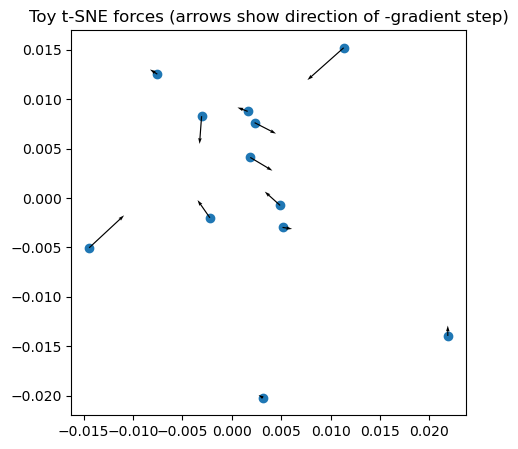

In [14]:
def compute_Q_from_Y(Y):
    dist2 = pairwise_distances(Y, metric="euclidean", squared=True)
    np.fill_diagonal(dist2, np.inf)
    W = 1.0 / (1.0 + dist2)
    W[~np.isfinite(W)] = 0.0
    Q = W / np.sum(W)
    return np.maximum(Q, 1e-12)

def forces(P, Y):
    Q = compute_Q_from_Y(Y)
    dist2 = pairwise_distances(Y, metric="euclidean", squared=True)
    np.fill_diagonal(dist2, np.inf)
    w = 1.0 / (1.0 + dist2)
    w[~np.isfinite(w)] = 0.0

    F = np.zeros_like(Y)
    for i in range(Y.shape[0]):
        diff = (Y[i] - Y)  # (n,2)
        coeff = (P[i] - Q[i]) * w[i]  # (n,)
        F[i] = 4.0 * np.sum(coeff[:, None] * diff, axis=0)
    return F, Q

# Toy system
rng = np.random.RandomState(1)
X_toy = StandardScaler().fit_transform(rng.randn(12, 5))
P_toy, _ = compute_P_matrix(X_toy, perplexity=5)

Y_toy = rng.randn(12, 2) * 0.01
F, Q_toy = forces(P_toy, Y_toy)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(Y_toy[:,0], Y_toy[:,1])
ax.quiver(Y_toy[:,0], Y_toy[:,1], -F[:,0], -F[:,1], angles="xy",
          scale_units="xy", scale=1.0, width=0.003)
ax.set_title("Toy t-SNE forces (arrows show direction of -gradient step)")
ax.set_aspect("equal", "box")
plt.show()


---

# 10) Optimization details (learning rate, early exaggeration, init)

From the slides:

- **Learning rate \(\eta\)**: too small → “blob”; reasonable (often 200–1000) → clusters form.
- **Early exaggeration**: multiplies \(P\) early on → helps separate clusters (“sorting phase”).
- **Initialization**: `pca` is often more stable than `random`.

We’ll make these effects visible on the digits subset.


In [15]:
def tsne_with_score(X, perplexity=30, learning_rate="auto", early_exaggeration=12,
                   init="pca", n_iter=800, seed=0):
    t0 = perf_counter()
    Y = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate=learning_rate,
        early_exaggeration=early_exaggeration,
        init=init,
        max_iter=n_iter,
        random_state=seed
    ).fit_transform(X)
    t1 = perf_counter()
    score = trustworthiness(X, Y, n_neighbors=10)
    return Y, (t1-t0), score

# Quick learning-rate comparison
rates = [10, 200, 1000]
for lr in rates:
    Y_lr, dt, tw = tsne_with_score(X_small, perplexity=30, learning_rate=lr, init="pca", seed=0, n_iter=600)
    fig = px.scatter(x=Y_lr[:,0], y=Y_lr[:,1], color=y_small.astype(str), opacity=0.75,
                     title=f"Digits t-SNE (perp=30, init=pca, lr={lr}) — time={dt:.1f}s, trust@10={tw:.3f}")
    fig.show()


## Interactive t‑SNE playground (recommended)

Practical workflow (slides):

1) **Scale** your features  
2) Optionally **PCA to ~50 dims**  
3) Sweep **perplexity (5–50)**  
4) Try multiple **seeds**  
5) Interpret **locally**

Use the button to run (so sliders don’t trigger a rerun every time).


In [16]:
# Data for playground (digits subset)
X_base = X_scaled[idx]
y_base = y_small

def preprocess(X, use_pca=True, pca_dim=40):
    if use_pca:
        return PCA(n_components=pca_dim, random_state=0).fit_transform(X)
    return X

if HAS_WIDGETS:
    use_pca = widgets.Checkbox(value=True, description="PCA before t-SNE")
    pca_dim = widgets.IntSlider(value=40, min=10, max=64, step=2, description="PCA dim")
    perp = widgets.IntSlider(value=30, min=5, max=60, step=1, description="perplexity")
    lr = widgets.IntSlider(value=200, min=10, max=1500, step=10, description="learning rate")
    ee = widgets.FloatSlider(value=12.0, min=4.0, max=30.0, step=0.5, description="early_exag")
    init = widgets.Dropdown(options=["pca", "random"], value="pca", description="init")
    iters = widgets.IntSlider(value=800, min=250, max=2000, step=50, description="n_iter")
    seed = widgets.IntSlider(value=0, min=0, max=20, step=1, description="seed")
    run_btn = widgets.Button(description="Run", button_style="primary")
    out = widgets.Output()

    def _run(_):
        with out:
            out.clear_output(wait=True)
            Xp = preprocess(X_base, use_pca.value, pca_dim.value)
            Y, dt, tw = tsne_with_score(
                Xp,
                perplexity=perp.value,
                learning_rate=lr.value,
                early_exaggeration=ee.value,
                init=init.value,
                n_iter=iters.value,
                seed=seed.value
            )
            fig = px.scatter(x=Y[:,0], y=Y[:,1], color=y_base.astype(str), opacity=0.75,
                             title=f"t-SNE digits | perp={perp.value}, lr={lr.value}, ee={ee.value}, init={init.value}, PCA={use_pca.value}({pca_dim.value}) | time={dt:.1f}s | trust@10={tw:.3f}")
            fig.show()
    run_btn.on_click(_run)

    display(widgets.VBox([
        widgets.HBox([use_pca, pca_dim]),
        widgets.HBox([perp, lr, ee]),
        widgets.HBox([init, iters, seed, run_btn]),
        out
    ]))
else:
    print("ipywidgets not found. Install with: pip install ipywidgets")
    print("Manual example:")
    print("  Xp = preprocess(X_base, True, 40)")
    print("  Y, dt, tw = tsne_with_score(Xp, perplexity=30, learning_rate=200, early_exaggeration=12, init='pca', n_iter=800, seed=0)")


---

# 11) Preprocessing — scaling and PCA-before-t‑SNE

Slides highlight:

- **Scaling matters**: different feature scales distort distances → distort neighborhoods.
- **PCA before t‑SNE**: reduces noise + speeds up (common: 30–50 dims).

We’ll compare quick views on the same digits subset.


In [17]:
X_raw_small = X[idx]          # raw subset
X_scaled_small = X_scaled[idx]  # scaled subset
X_pca40 = PCA(n_components=40, random_state=0).fit_transform(X_scaled_small)

# PCA(2D) on raw vs scaled
X_raw_pca2 = PCA(n_components=2, random_state=0).fit_transform(X_raw_small)
X_scaled_pca2 = PCA(n_components=2, random_state=0).fit_transform(X_scaled_small)

px.scatter(x=X_raw_pca2[:,0], y=X_raw_pca2[:,1], color=y_small.astype(str),
           title="PCA(2D) on RAW features (subset)", opacity=0.75).show()

px.scatter(x=X_scaled_pca2[:,0], y=X_scaled_pca2[:,1], color=y_small.astype(str),
           title="PCA(2D) on SCALED features (subset)", opacity=0.75).show()

# Typical pipeline: scale + PCA(40) + t-SNE
Y_tsne, dt, tw = tsne_with_score(X_pca40, perplexity=30, learning_rate=200, init="pca", seed=0, n_iter=700)
px.scatter(x=Y_tsne[:,0], y=Y_tsne[:,1], color=y_small.astype(str),
           title=f"t-SNE after scaling + PCA(40) | time={dt:.1f}s | trust@10={tw:.3f}", opacity=0.75).show()


---

# 12) What to report when you show a t‑SNE plot (from the slides)

When you publish or present a t‑SNE figure, report at minimum:

- preprocessing: **scaling? PCA dims?**
- `perplexity`
- `learning_rate`
- `early_exaggeration`
- initialization (`pca` or `random`)
- number of iterations (`n_iter`)
- random seed (or multiple seeds)

Reason: t‑SNE is stochastic and sensitive to hyperparameters.


---

# 13) Pitfalls (with quick visuals)

## Pitfall 1 — Axes are meaningless
Rotate the embedding; meaning is unchanged.

## Pitfall 5 — Confirmation bias
Different seeds can give different global layouts. Don’t cherry-pick.


In [18]:
# Pitfall 1: rotate an embedding (same neighborhood relationships, different axes)
Y = Y_tsne.copy()
theta = np.deg2rad(35)
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
Y_rot = Y @ R.T

px.scatter(x=Y[:,0], y=Y[:,1], color=y_small.astype(str),
           title="Original t-SNE embedding", opacity=0.75).show()

px.scatter(x=Y_rot[:,0], y=Y_rot[:,1], color=y_small.astype(str),
           title="Same embedding, rotated by 35° (axes are meaningless)", opacity=0.75).show()


In [19]:
# Pitfall 5: different seeds can change global arrangement
for s in [0, 1, 2]:
    Y_s, dt, tw = tsne_with_score(X_pca40, perplexity=30, learning_rate=200, init="pca", seed=s, n_iter=700)
    px.scatter(x=Y_s[:,0], y=Y_s[:,1], color=y_small.astype(str), opacity=0.75,
               title=f"t-SNE with seed={s} (global layout can change) | trust@10={tw:.3f}").show()


---

# 14) Validating your embedding

A simple quantitative check aligned with the lecture’s “verify / run multiple seeds” message:

- **Trustworthiness** measures how well k‑NN relationships are preserved from high‑D to low‑D.

We’ll sweep perplexity and see how trustworthiness changes.


In [20]:
perps = [5, 10, 20, 30, 40, 50]
scores = []
times = []

for p in perps:
    Yp, dt, tw = tsne_with_score(X_pca40, perplexity=p, learning_rate=200, init="pca", seed=0, n_iter=600)
    scores.append(tw)
    times.append(dt)

go.Figure([go.Scatter(x=perps, y=scores, mode="lines+markers")]).update_layout(
    title="Trustworthiness@10 vs perplexity (digits subset)",
    xaxis_title="perplexity",
    yaxis_title="trustworthiness (higher is better)"
).show()

go.Figure([go.Bar(x=[str(p) for p in perps], y=times)]).update_layout(
    title="Runtime vs perplexity (digits subset)",
    xaxis_title="perplexity",
    yaxis_title="seconds"
).show()


---

# 15) Computational cost and approximations

Exact t‑SNE needs (roughly) **all pairwise interactions** → \(O(n^2)\) memory/time.

That’s why approximations exist (Barnes–Hut, FFT-based methods).  
Below is a quick empirical reminder: pairwise distance matrices scale as \(n^2\).


In [21]:
def pairwise_cost_demo(ns=(200, 400, 800, 1200), d=50, seed=0):
    rng = np.random.RandomState(seed)
    times = []
    for n in ns:
        Xr = rng.randn(n, d)
        t0 = perf_counter()
        _ = pairwise_distances(Xr, squared=True)  # O(n^2)
        t1 = perf_counter()
        times.append(t1-t0)
    go.Figure([go.Scatter(x=list(ns), y=times, mode="lines+markers")]).update_layout(
        title="Pairwise distance computation scales ~ O(n^2)",
        xaxis_title="n points",
        yaxis_title="seconds (pairwise_distances)"
    ).show()

pairwise_cost_demo()


---

# 16) A brief note on UMAP (from the slides)

UMAP is a popular modern alternative:

- still **nonlinear + neighborhood-based**
- often **faster** and scales better
- often preserves a bit more global structure

Lecture recommendation: **run both t‑SNE and UMAP**; if they agree, confidence increases.

If `umap-learn` is installed, the next cell compares quickly. If not, skip it.


In [22]:
try:
    import umap
    HAS_UMAP = True
except Exception:
    HAS_UMAP = False

print("UMAP available:", HAS_UMAP)

if HAS_UMAP:
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=0)
    t0 = perf_counter()
    Y_umap = reducer.fit_transform(X_pca40)
    t1 = perf_counter()
    px.scatter(x=Y_umap[:,0], y=Y_umap[:,1], color=y_small.astype(str), opacity=0.75,
               title=f"UMAP on digits subset (time={t1-t0:.1f}s)").show()


UMAP available: False


---

# 17) Summary — 5 rules of thumb (from the slides)

1. **Preprocess:** scale features to a standard variance  
2. **Denoise:** run PCA first (e.g., to 50 dims)  
3. **Sweep:** test multiple perplexities (5–50)  
4. **Verify:** run multiple random seeds  
5. **Interpret locally:** ignore global distance, size, and axes

> **t‑SNE is a topology map (who is next to whom), not a metric map.**


---

# 18) Closing thoughts

To apply t‑SNE on your own data:

- scale + PCA(30–50)
- run several perplexities + seeds
- only use labels for **coloring after** embedding (not for fitting)
- validate neighborhoods (trustworthiness / kNN agreement)
- compare with UMAP

Happy embedding!


---

# Appendix A) Dimensionality reduction landscape (quick taxonomy)

A simplified map (from the lecture):

| Goal | Typical methods | What they tend to preserve |
|---|---|---|
| Linear compression / denoising | PCA | global variance directions |
| Pairwise-distance preservation | Classical MDS | global distances (approximately) |
| Manifold learning (geodesic) | Isomap | manifold distances (if manifold assumptions hold) |
| Local reconstruction | LLE | local linear neighborhoods |
| Neighborhood visualization | t‑SNE | local neighborhoods (strongly), not global geometry |
| Fast modern neighborhood viz | UMAP | local neighborhoods + often a bit more global structure |

t‑SNE/UMAP are best thought of as **neighborhood maps**: “who sits next to whom”.


---

# Appendix B) Initialization and early exaggeration (visual effect)

Two knobs highlighted in the slides:

- **Initialization**: `init="pca"` is often more stable than `init="random"`
- **Early exaggeration**: increases attractive forces early → helps clusters separate (a “sorting phase”)

Let’s compare on the same digits subset.


In [23]:
# Init comparison (same params, different init)
params = dict(perplexity=30, learning_rate=200, early_exaggeration=12, n_iter=700, seed=0)

Ys = {}
for init_mode in ["pca", "random"]:
    Y, dt, tw = tsne_with_score(X_pca40, init=init_mode, **params)
    Ys[init_mode] = (Y, dt, tw)

for init_mode in ["pca", "random"]:
    Y, dt, tw = Ys[init_mode]
    px.scatter(x=Y[:,0], y=Y[:,1], color=y_small.astype(str), opacity=0.75,
               title=f"t-SNE init={init_mode} | time={dt:.1f}s | trust@10={tw:.3f}").show()


In [24]:
# Early exaggeration comparison (same params, different ee)
ees = [4.0, 12.0, 24.0]
rows = []
for ee in ees:
    Y, dt, tw = tsne_with_score(X_pca40, perplexity=30, learning_rate=200, early_exaggeration=ee,
                               init="pca", n_iter=700, seed=0)
    rows.append(dict(ee=str(ee), dt=dt, tw=tw, x=Y[:,0], y=Y[:,1], label=y_small.astype(str)))

# Build a long-form table for facet plotting
import pandas as pd
df = pd.concat([pd.DataFrame({"x": r["x"], "y": r["y"], "digit": r["label"], "ee": r["ee"]}) for r in rows],
               ignore_index=True)

fig = px.scatter(df, x="x", y="y", color="digit", facet_col="ee", facet_col_spacing=0.04,
                 opacity=0.75, title="Early exaggeration effect (facet by ee)")
fig.update_xaxes(matches=None)
fig.update_yaxes(matches=None)
fig.show()

for r in rows:
    print(f"ee={r['ee']:>4} | time={r['dt']:.1f}s | trust@10={r['tw']:.3f}")


ee= 4.0 | time=1.0s | trust@10=0.981
ee=12.0 | time=1.1s | trust@10=0.981
ee=24.0 | time=1.2s | trust@10=0.980


---

# Appendix C) Pitfall 2 & 3 demos

## Pitfall 2 — Global distances are illusions
Cluster-to-cluster spacing can change a lot with perplexity / seed, while local neighborhoods remain plausible.

## Pitfall 3 — Sizes and densities are distorted
t‑SNE uses adaptive bandwidths \(\sigma_i\), which can make dense and sparse groups look similarly sized.


In [25]:
# Pitfall 2: same data, different perplexity -> different global spacing
perps = [5, 50]
rows = []
for p in perps:
    Y, dt, tw = tsne_with_score(X_pca40, perplexity=p, learning_rate=200, early_exaggeration=12,
                               init="pca", n_iter=700, seed=0)
    rows.append(dict(perp=str(p), dt=dt, tw=tw, x=Y[:,0], y=Y[:,1], digit=y_small.astype(str)))

df = pd.concat([pd.DataFrame({"x": r["x"], "y": r["y"], "digit": r["digit"], "perplexity": r["perp"]})
                for r in rows], ignore_index=True)

fig = px.scatter(df, x="x", y="y", color="digit", facet_col="perplexity", facet_col_spacing=0.04,
                 opacity=0.75, title="Pitfall 2: Global spacing changes with perplexity")
fig.update_xaxes(matches=None)
fig.update_yaxes(matches=None)
fig.show()

for r in rows:
    print(f"perp={r['perp']:>2} | time={r['dt']:.1f}s | trust@10={r['tw']:.3f}")


perp= 5 | time=1.1s | trust@10=0.976
perp=50 | time=1.2s | trust@10=0.980


In [26]:
# Pitfall 3: density distortion on synthetic dense vs sparse clusters

rng = np.random.RandomState(0)

# High-D "reality": one dense cluster, one sparse cluster
n_dense, n_sparse, d = 350, 80, 20
dense = rng.randn(n_dense, d) * 0.30
sparse = rng.randn(n_sparse, d) * 1.30 + 2.5  # shifted + broader
X_ds = np.vstack([dense, sparse])
y_ds = np.array(["dense"]*n_dense + ["sparse"]*n_sparse)

X_ds_scaled = StandardScaler().fit_transform(X_ds)
X_ds_pca2 = PCA(n_components=2, random_state=0).fit_transform(X_ds_scaled)

px.scatter(x=X_ds_pca2[:,0], y=X_ds_pca2[:,1], color=y_ds,
           title="High-D reality (shown via PCA2D): dense vs sparse group", opacity=0.8).show()

# t-SNE tends to equalize perceived cluster sizes/densities
X_ds_pca10 = PCA(n_components=10, random_state=0).fit_transform(X_ds_scaled)
Y_ds, dt, tw = tsne_with_score(X_ds_pca10, perplexity=30, learning_rate=200, early_exaggeration=12,
                              init="pca", n_iter=800, seed=0)

px.scatter(x=Y_ds[:,0], y=Y_ds[:,1], color=y_ds,
           title=f"t-SNE view: sizes/densities often distorted | time={dt:.1f}s | trust@10={tw:.3f}",
           opacity=0.8).show()


---

# Appendix D) Labeled data: best practice (the “golden rule”)

From the slides:

- **Never** use labels (or target) as input features to t‑SNE.
- Fit t‑SNE on the features only.
- Use labels only for **coloring** *after* the embedding is produced.

Reason: it is extremely easy to fool yourself into seeing “perfect separation” that is driven by choices of parameters/seed.


In [27]:
# A simple kNN neighborhood agreement check (local topology focus)

def knn_overlap(X_high, Y_low, k=10):
    # For each point, compute fraction of shared kNN between high-D and low-D
    from sklearn.neighbors import NearestNeighbors
    nbrs_high = NearestNeighbors(n_neighbors=k+1).fit(X_high)
    nbrs_low = NearestNeighbors(n_neighbors=k+1).fit(Y_low)
    ind_high = nbrs_high.kneighbors(return_distance=False)[:, 1:]  # drop self
    ind_low = nbrs_low.kneighbors(return_distance=False)[:, 1:]
    overlaps = []
    for i in range(X_high.shape[0]):
        overlaps.append(len(set(ind_high[i]).intersection(ind_low[i])) / k)
    return np.array(overlaps)

# Use the digits subset pipeline embedding Y_tsne already computed earlier
over = knn_overlap(X_pca40, Y_tsne, k=10)
fig = go.Figure([go.Histogram(x=over, nbinsx=20)])
fig.update_layout(title="Local validation: kNN overlap fraction (k=10)",
                  xaxis_title="fraction of shared neighbors", yaxis_title="count")
fig.show()

print("Mean overlap:", float(over.mean()), "Median:", float(np.median(over)))


Mean overlap: 0.50575 Median: 0.5
